<a href="https://colab.research.google.com/github/SandroBolkvadze/Facial-Expression-Recognition-Kaggle-Competition/blob/main/facial-expression-recognition-01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Install dependencies

In [33]:
! pip install --upgrade kaggle wandb --quiet

# Imports

In [34]:
import pandas as pd
import numpy as np

import torch
import torchvision.transforms as transforms
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import SGD, Adam

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

# Use GPU
USE_GPU = True
device = 'cuda' if USE_GPU and torch.cuda.is_available() else 'cpu'
print('Device available:', device)

Device available: cuda


# Mount Google Drive

In [35]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Copy Access Token

In [36]:
! mkdir ~/.kaggle
! cp /content/drive/MyDrive/kaggle/access_token ~/.kaggle/access_token
! chmod 600 ~/.kaggle/access_token

mkdir: cannot create directory ‘/root/.kaggle’: File exists


# Download Kaggle Competition Data

In [37]:
! kaggle competitions download -c challenges-in-representation-learning-facial-expression-recognition-challenge

challenges-in-representation-learning-facial-expression-recognition-challenge.zip: Skipping, found more recently modified local copy (use --force to force download)


# Unzip Kaggle Competition Data

In [38]:
! unzip challenges-in-representation-learning-facial-expression-recognition-challenge

Archive:  challenges-in-representation-learning-facial-expression-recognition-challenge.zip
replace example_submission.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: example_submission.csv  
replace fer2013.tar.gz? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: fer2013.tar.gz          y
y
y

replace icml_face_data.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename:   inflating: icml_face_data.csv      y
y
y

replace test.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename:   inflating: test.csv                
replace train.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename:   inflating: train.csv               y



# Wandb Login

In [39]:
import wandb
! wandb login --relogin

wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter: 
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


# Read & Transform Dataset

In [40]:
# Simple function for transforming 'pixels' elements
def pixels_to_image(pixels_str):
  pixels = np.array(pixels_str.split(), dtype=np.uint8)
  pixels = pixels.reshape(48, 48)
  return pixels

In [41]:
df = pd.read_csv('./icml_face_data.csv')

# Rename columns
df.columns = ['emotion', 'Usage', 'pixels']

# Choose Training part
df = df[df['Usage'] == 'Training']

# Drop 'Usage' column
df = df.drop(columns=['Usage'])

# Transform 'pixels' elements to numpy array in advance
df['pixels'] = df['pixels'].apply(pixels_to_image)


In [42]:
X = df.drop(columns=['emotion'])
y = df['emotion']

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')

X shape: (28709, 1)
y shape: (28709,)


# Split Dataset

In [43]:
train_size = .7
val_size   = .15
test_size  = .15

# Split full dataset into train and val/test sets
X_train, X_val_test, y_train, y_val_test = train_test_split(
    X, y,
    test_size=(val_size+test_size)/(train_size+val_size+test_size),
    stratify=y,
)

# Split val/test dataset into 50/50 val and test sets
X_val, X_test, y_val, y_test = train_test_split(
    X_val_test, y_val_test,
    test_size=test_size/(val_size+test_size),
    stratify=y_val_test,
)

# Split full dataset into 70/15/15 train/val/test sets
print(f'X_train shape {X_train.shape} and y_train shape {y_train.shape}')
print(f'X_val shape {X_val.shape} and y_val shape {y_val.shape}')
print(f'X_test shape {X_test.shape} and y_test shape {y_test.shape}')

X_train shape (20096, 1) and y_train shape (20096,)
X_val shape (4306, 1) and y_val shape (4306,)
X_test shape (4307, 1) and y_test shape (4307,)


In [44]:
# Check if label distributions are same in train/val/test sets
y_train_dist = y_train.value_counts() / y_train.value_counts().sum()
y_val_dist   = y_val.value_counts()   / y_val.value_counts().sum()
y_test_dist  = y_test.value_counts()  / y_test.value_counts().sum()

# Should have roughly equal numbers across rows of 'emotions'
y_dist = pd.DataFrame({
    'y_train': y_train_dist,
    'y_val'  : y_val_dist,
    'y_test' : y_test_dist,
})

print(y_dist)

          y_train     y_val    y_test
emotion                              
3        0.251294  0.251277  0.251451
6        0.172920  0.173014  0.172974
4        0.168242  0.168137  0.168331
2        0.142715  0.142592  0.142791
0        0.139182  0.139108  0.139076
5        0.110470  0.110543  0.110286
1        0.015177  0.015327  0.015092


# Transform Raw Pixels

In [45]:
# Calculate mean pixel over whole train dataset
mean_pixel = X_train['pixels'].apply(np.mean).mean() / 255.0

# Transform 2d numpy pixel array
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=(mean_pixel,), std=(1.0,)),
])

# Custom Image Dataset

In [46]:
class ImageDataset(Dataset):
  def __init__(self, X, y, transform=None):
    self.X = X
    self.y = torch.tensor(y.values)
    self.transform = transform

  def __len__(self):
    return self.X.shape[0]

  def __getitem__(self, index):
    image = self.X.iloc[index, 0]
    label = self.y[index]

    if self.transform:
      image = self.transform(image)

    return image, label

# Datasets

In [47]:
train_dataset = ImageDataset(X_train, y_train, transform)
val_dataset   = ImageDataset(X_val,   y_val,   transform)
test_dataset  = ImageDataset(X_test,  y_test,  transform)

# Check Accuracy & Loss

In [48]:
def evaluate(loader, model, criterion=None):
  model.eval()

  total_loss, correct, total = 0, 0, 0

  with torch.no_grad():
    for t, (x, y) in enumerate(loader):
      x, y = x.to(device), y.to(device)

      scores = model(x)
      _, preds = scores.max(1)

      if criterion:
        total_loss += criterion(scores, y).item()

      correct += (preds == y).sum().item()
      total += y.shape[0]

  return total_loss / len(loader), correct / total

# Train Epoch

In [ ]:
def train_epoch(loader, model, criterion, optimizer):
  model.train()

  total_loss, correct, total = .0, 0, 0

  for t, (x, y) in enumerate(loader):
      x, y = x.to(device), y.to(device)

      # Zero out grads
      optimizer.zero_grad()

      # Calculate scores
      scores = model(x)

      # Calculate loss
      loss = criterion(scores, y)

      # Backpropagation
      loss.backward()

      # Update model parameters
      optimizer.step()

      with torch.no_grad():
        # Update Train stats
        _, preds    = scores.max(1)
        total_loss += loss.item()
        correct    += (preds == y).sum().item()
        total      += y.shape[0]

  return total_loss / len(loader), correct / total

# EarlyStopper

In [ ]:
import copy

class EarlyStopper:
  def __init__(self, patience=1, min_delta=0):
    self.patience = patience
    self.min_delta = min_delta
    self.counter = 0
    self.best_loss = np.inf
    self.early_stop = False
    self.best_weights = None

  def __call__(self, val_loss, model):
    if val_loss < self.best_loss - self.min_delta:
      self.best_loss = val_loss
      self.counter = 0
      self.best_weights = copy.deepcopy(model.state_dict())
    else:
      self.counter += 1
      if self.counter >= self.patience:
        self.early_stop = True

    return self.early_stop


# Train

In [49]:
def train(loader_train, loader_val, model, criterion, optimizer, epochs=10, early_stopper=None, use_wandb=False):
  history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

  e = 0
  while e < epochs or early_stopper:
    e += 1

    # Train history
    train_loss, train_acc = train_epoch(loader_train, model, criterion, optimizer)
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)

    # Validation history
    val_loss, val_acc = evaluate(loader_val, model, criterion)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    # Print statistics
    print('[Epoch %d / %d]' % (e + 1, epochs,))
    print('train_loss: %.4f; train_acc: %.4f; val_acc: %.4f' % (history['train_loss'][-1], history['train_acc'][-1], val_acc,))
    print()

    if use_wandb:
      wandb.log({
        'epoch':          e + 1,
        'train_loss':     history['train_loss'][-1],
        'train_accuracy': history['train_acc'][-1],
        'val_loss':       history['val_loss'][-1],
        'val_accuracy':   history['val_acc'][-1],
      })

    if early_stopper and early_stopper(val_loss, model):
      model.load_state_dict(early_stopper.best_weights)
      print('Early stopping')
      break

  return history

# Two Layer FC

In [54]:
class TwoLayerFC(nn.Module):
  def __init__(self, input_size, hidden_size, output_size):
    super().__init__()

    # Initialize Layers
    self.fc1 = nn.Linear(input_size, hidden_size)
    self.fc2 = nn.Linear(hidden_size, output_size)
    self.activation = nn.ReLU()
    self.flatten = nn.Flatten()

    # Initialize weights & biases
    nn.init.kaiming_normal_(self.fc1.weight, nonlinearity='relu')
    nn.init.zeros_(self.fc1.bias)

    nn.init.xavier_normal_(self.fc2.weight)
    nn.init.zeros_(self.fc2.bias)

  def forward(self, x):
    # Flatten input
    x = self.flatten(x)

    # Apply Linear -> ReLU
    x = self.activation(self.fc1(x))

    # Apply Linear
    x = self.fc2(x)

    return x

# Check: Loss is reasonable for untrained model

In [55]:
# Create Train DataLoader
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

# Create model, criterion, optimizer
model = TwoLayerFC(48*48, 64, 7).to(device)
criterion = nn.CrossEntropyLoss()

loss, _ = evaluate(train_loader, model, criterion)
print('Loss: %.4f' % loss)

Loss: 1.9524


# Check: Model can overfit small data

In [56]:
small_data_size = 32

X_small_train = X_test[:small_data_size]
y_small_train = y_test[:small_data_size]

small_dataset = ImageDataset(X_small_train, y_small_train, transform)
small_loader  = DataLoader(small_dataset, batch_size=small_data_size, shuffle=True)

In [57]:
# Create model, criterion, optimizer
model = TwoLayerFC(48*48, 64, 7).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = SGD(model.parameters(), lr=5e-2)

# Train model
_ = train(small_loader, small_loader, model, criterion, optimizer, epochs=15, use_wandb=False)

[Epoch 1 / 15]
train_loss: 1.9809; train_acc: 0.1250; val_acc: 0.2812

[Epoch 2 / 15]
train_loss: 1.7685; train_acc: 0.2812; val_acc: 0.4062

[Epoch 3 / 15]
train_loss: 1.6135; train_acc: 0.4062; val_acc: 0.4688

[Epoch 4 / 15]
train_loss: 1.4860; train_acc: 0.4688; val_acc: 0.5312

[Epoch 5 / 15]
train_loss: 1.3808; train_acc: 0.5312; val_acc: 0.7188

[Epoch 6 / 15]
train_loss: 1.2946; train_acc: 0.7188; val_acc: 0.8125

[Epoch 7 / 15]
train_loss: 1.2189; train_acc: 0.8125; val_acc: 0.8750

[Epoch 8 / 15]
train_loss: 1.1506; train_acc: 0.8750; val_acc: 0.9375

[Epoch 9 / 15]
train_loss: 1.0865; train_acc: 0.9375; val_acc: 0.9375

[Epoch 10 / 15]
train_loss: 1.0301; train_acc: 0.9375; val_acc: 0.9688

[Epoch 11 / 15]
train_loss: 0.9778; train_acc: 0.9688; val_acc: 0.9688

[Epoch 12 / 15]
train_loss: 0.9285; train_acc: 0.9688; val_acc: 0.9688

[Epoch 13 / 15]
train_loss: 0.8831; train_acc: 0.9688; val_acc: 0.9688

[Epoch 14 / 15]
train_loss: 0.8413; train_acc: 0.9688; val_acc: 0.9688

[

# Check: Activation statistics are reasonable

In [52]:
# activation_stats = []

# def get_activation_hook(layer_name):
#   def hook(module, input, output):
#     out = output.detach().cpu()
#     activation_stats.append({
#       'layer_name': layer_name,
#       'mean': out.mean().item(),
#       'std': out.std().item(),
#       'data': out.flatten().tolist(),
#     })
#   return hook

In [53]:
# model = TwoLayerFC(48*48, 64, 7).to(device)

# for name, layer in model.named_modules():
#   if isinstance(layer, nn.Linear):
#     layer.register_forward_hook(get_activation_hook(name))

# model()

# Train TwoLayerFC model

In [61]:
config={
    'epochs': 200,
    'learning_rate': 1e-3,
    'batch_size': 64,
    'architecture': 'TwoLayerFC',
    'input_size': 48*48,
    'hidden_size': 64,
    'output_size': 7,
    'optimizer': 'Adam',
    'weight_decay': 1e-4,
    'loss_function': 'CrossEntropyLoss',
}

run = wandb.init(
    project='Facial_Expression_Recognition_01',
    name="TwoLayerFC",
    config=config
)

In [62]:
# Create Train and Validation DataLoaders
train_loader = DataLoader(train_dataset, batch_size=config['batch_size'], shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=config['batch_size'], shuffle=True)

# Create model, criterion, optimizer
model = TwoLayerFC(config['input_size'], config['hidden_size'], config['output_size']).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=config['learning_rate'], weight_decay=1e-4)

# Init wandb
wandb.watch(model, log='all')

# Train model
history = train(train_loader, val_loader, model, criterion, optimizer, epochs=config['epochs'], print_every=1, use_wandb=True)

# Save model
torch.save(model.state_dict(), 'Facial_Expression_Recognition_01_TwoLayerFC.pth')
wandb.save('Facial_Expression_Recognition_01_TwoLayerFC.pth')

# Finish wandb
wandb.finish()

[Epoch 1 / 200]
train_loss: 1.7043; train_acc: 0.3347; val_acc: 0.3535

[Epoch 2 / 200]
train_loss: 1.5831; train_acc: 0.3912; val_acc: 0.3662

[Epoch 3 / 200]
train_loss: 1.5241; train_acc: 0.4173; val_acc: 0.3795

[Epoch 4 / 200]
train_loss: 1.4812; train_acc: 0.4391; val_acc: 0.3839

[Epoch 5 / 200]
train_loss: 1.4408; train_acc: 0.4550; val_acc: 0.3774

[Epoch 6 / 200]
train_loss: 1.3973; train_acc: 0.4723; val_acc: 0.3790

[Epoch 7 / 200]
train_loss: 1.3726; train_acc: 0.4825; val_acc: 0.3906

[Epoch 8 / 200]
train_loss: 1.3315; train_acc: 0.5023; val_acc: 0.3976

[Epoch 9 / 200]
train_loss: 1.3050; train_acc: 0.5160; val_acc: 0.3837

[Epoch 10 / 200]
train_loss: 1.2773; train_acc: 0.5264; val_acc: 0.3825

[Epoch 11 / 200]
train_loss: 1.2393; train_acc: 0.5399; val_acc: 0.3869

[Epoch 12 / 200]
train_loss: 1.2150; train_acc: 0.5502; val_acc: 0.3846

[Epoch 13 / 200]
train_loss: 1.1872; train_acc: 0.5636; val_acc: 0.3922

[Epoch 14 / 200]
train_loss: 1.1562; train_acc: 0.5765; val_

wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


[Epoch 200 / 200]
train_loss: 0.1402; train_acc: 0.9587; val_acc: 0.3676



epoch,▁▁▁▂▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▄▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇███
train_accuracy,▁▂▂▃▄▄▅▅▅▅▆▇▇▇▇▇▇▇▇▇████████████████████
train_loss,█▅▅▅▅▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_accuracy,▁▃▅█▆██▇▆▅▆▆▆▆▅▃▄▆▄▅▅▅▆▄▆▆▄▅▃▃▄▄▅▅▆▃▃▄▃▃
val_loss,▁▁▁▁▂▂▂▃▃▃▄▄▄▄▄▅▅▅▅▆▆▆▆▆▆▇▇▆▆▇▇▇▇▇█▇████
epoch,200
train_accuracy,0.9587
train_loss,0.14023
val_accuracy,0.36763
val_loss,5.01466


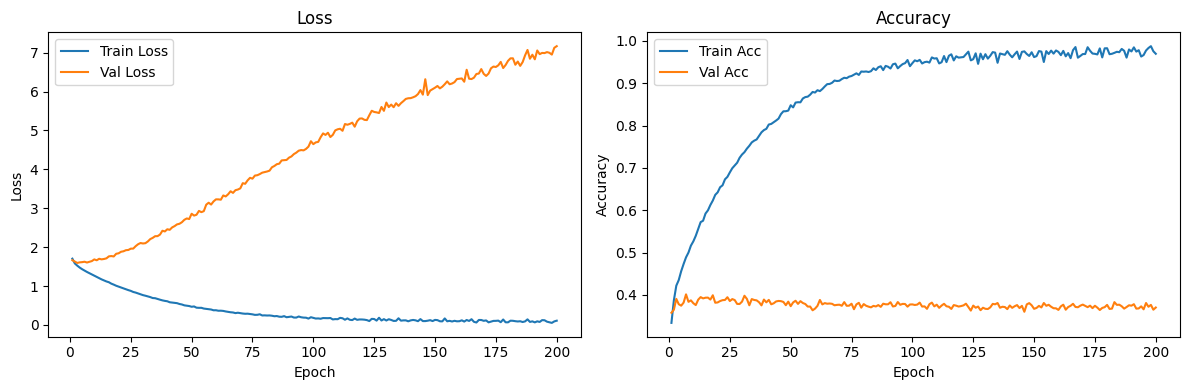

In [60]:
def plot_history(train_loss, train_acc, val_loss, val_acc):
    epochs = range(1, len(train_loss) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    # Loss
    ax1.plot(epochs, train_loss, label='Train Loss')
    ax1.plot(epochs, val_loss, label='Val Loss')
    ax1.set_title('Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()

    # Accuracy
    ax2.plot(epochs, train_acc, label='Train Acc')
    ax2.plot(epochs, val_acc, label='Val Acc')
    ax2.set_title('Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.legend()

    plt.tight_layout()
    plt.show()

plot_history(history['train_loss'], history['train_acc'], history['val_loss'], history['val_acc'])